<a href="https://colab.research.google.com/github/AnjalyKuriakose98/fake-news-detection-NLP/blob/main/Week1_Data_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
fake_df = pd.read_csv("/Fake.csv")
true_df = pd.read_csv("/True.csv")

In [4]:
print("Fake news dataset:", fake_df.shape)
print("Real news dataset:", true_df.shape)

Fake news dataset: (23481, 4)
Real news dataset: (21417, 4)


In [6]:
fake_df.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [7]:
true_df.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [8]:
fake_df["label"] = 0         # Add labels to the datasets
true_df["label"] = 1

print("Fake News:")
display(fake_df.head())

print("Real News:")
display(true_df.head())

Fake News:


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


Real News:


,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


In [9]:
df = pd.concat([fake_df, true_df], ignore_index=True)  # Combine fake and real news into one dataset

print("Combined dataset shape:", df.shape)
display(df.head())

Combined dataset shape: (44898, 5)


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [10]:
df.info()    # Basic information about the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB


In [11]:
df["label"].value_counts()  # Check the number of fake and real articles

,count
label,
0,23481
1,21417


In [12]:
df.isnull().sum()  # Check missing values

,0
title,0
text,0
subject,0
date,0
label,0


In [13]:
print("Number of duplicate rows:", df.duplicated().sum())    # Check duplicate rows

Number of duplicate rows: 209


In [14]:
df = df.drop_duplicates()  # Remove duplicate rows
df = df.reset_index(drop=True)    # Reset the row numbers

print("Dataset size after removing duplicates:", df.shape)
print("Remaining duplicates:", df.duplicated().sum())

Dataset size after removing duplicates: (44689, 5)
Remaining duplicates: 0


In [15]:
empty_text = (df["text"].str.strip() == "").sum()      # Check empty text articles

print("Number of empty text articles:", empty_text)

Number of empty text articles: 631


In [16]:
empty_articles = df[df["text"].str.strip() == ""]         # Look at articles where the text is empty

print("Number of empty-text articles:", len(empty_articles))

empty_articles[["title", "text", "label"]].head(10)

Number of empty-text articles: 631


,title,text,label
10922,TAKE OUR POLL: Who Do You Think President Trum...,,0
11040,Joe Scarborough BERATES Mika Brzezinski Over “...,,0
11189,WATCH TUCKER CARLSON Scorch Sanctuary City May...,,0
11224,MAYOR OF SANCTUARY CITY: Trump Trying To Make ...,,0
11235,SHOCKER: Public School Turns Computer Lab Into...,,0
11240,BOOM! SEAN SPICER: “Trump Sold Hotels In Russi...,,0
11246,MICHAEL FLYNN’S LAWYER Releases Statement Scor...,,0
11248,ROB SCHNEIDER Nails The Russia Conspiracy Theo...,,0
11266,TREY GOWDY ON SPYING ON AMERICAN CITIZENS…Like...,,0
11267,SEAN SPICER CALLS OUT Race Baiting Journalist:...,,0


In [17]:
empty_articles["label"].value_counts()   # Check whether empty-text articles are Fake or Real

,count
label,
0,630
1,1


In [18]:
completely_empty = (
    (df["title"].str.strip() == "") &           # Check if both title AND text are empty
    (df["text"].str.strip() == "")
).sum()

print("Articles with both title and text empty:", completely_empty)

Articles with both title and text empty: 0


In [19]:
df["content"] = df["title"].fillna("") + " " + df["text"].fillna("")   # Combine the title and article text into one column

df[["title", "text", "content", "label"]].head()   # Display the new content column

,title,text,content,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,Donald Trump Sends Out Embarrassing New Year’...,0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,Drunk Bragging Trump Staffer Started Russian ...,0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",Sheriff David Clarke Becomes An Internet Joke...,0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",Trump Is So Obsessed He Even Has Obama’s Name...,0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,Pope Francis Just Called Out Donald Trump Dur...,0


In [20]:
import re

def clean_text(text):
    text = text.lower()      # Convert to lowercase

    text = re.sub(r"http\S+|www\S+", "", text)   # Remove website links

    text = re.sub(r"[^a-zA-Z\s]", " ", text)     # Remove numbers, punctuation and special characters

    text = re.sub(r"\s+", " ", text).strip()      # Remove extra spaces

    return text

In [21]:
df["clean_text"] = df["content"].apply(clean_text)

In [22]:
print("ORIGINAL TEXT:\n")
print(df["content"].iloc[0][:500])

print("\n-----------------------------------")

print("\nCLEANED TEXT:\n")
print(df["clean_text"].iloc[0][:500])

ORIGINAL TEXT:

 Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and  the very dishonest fake news media.  The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, 

-----------------------------------

CLEANED TEXT:

donald trump sends out embarrassing new year s eve message this is disturbing donald trump just couldn t wish all americans a happy new year and leave it at that instead he had to give a shout out to his enemies haters and the very dishonest fake news media the former reality show star had just one job to do and he couldn t do it as our country rapidly grows stronger and smarter i want to wish all of my friends supporters enem

In [23]:
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

print("Number of stop words:", len(stop_words))

Number of stop words: 198


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [24]:
def remove_stopwords(text):
    words = text.split()

    filtered_words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(filtered_words)

In [25]:
df["processed_text"] = df["clean_text"].apply(remove_stopwords)

In [26]:
print("CLEANED TEXT:\n")
print(df["clean_text"].iloc[0][:500])

print("\n-----------------------------------")

print("\nAFTER STOP-WORD REMOVAL:\n")
print(df["processed_text"].iloc[0][:500])

CLEANED TEXT:

donald trump sends out embarrassing new year s eve message this is disturbing donald trump just couldn t wish all americans a happy new year and leave it at that instead he had to give a shout out to his enemies haters and the very dishonest fake news media the former reality show star had just one job to do and he couldn t do it as our country rapidly grows stronger and smarter i want to wish all of my friends supporters enemies haters and even the very dishonest fake news media a happy and hea

-----------------------------------

AFTER STOP-WORD REMOVAL:

donald trump sends embarrassing new year eve message disturbing donald trump wish americans happy new year leave instead give shout enemies haters dishonest fake news media former reality show star one job country rapidly grows stronger smarter want wish friends supporters enemies haters even dishonest fake news media happy healthy new year president angry pants tweeted great year america country rapidly grows strong

In [27]:
class_counts = df["label"].value_counts()     # Count Fake and Real news

print("Fake News (0):", class_counts[0])
print("Real News (1):", class_counts[1])

Fake News (0): 23478
Real News (1): 21211


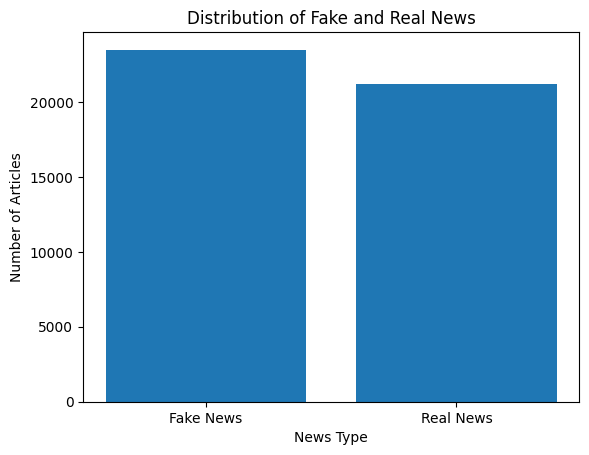

In [28]:
import matplotlib.pyplot as plt

labels = ["Fake News", "Real News"]
values = [class_counts[0], class_counts[1]]

plt.bar(labels, values)

plt.title("Distribution of Fake and Real News")
plt.xlabel("News Type")
plt.ylabel("Number of Articles")

plt.show()

In [29]:
df["word_count"] = df["processed_text"].apply(lambda x: len(x.split()))   # Calculate number of words in each processed article

df[["processed_text", "word_count", "label"]].head()

,processed_text,word_count,label
0,donald trump sends embarrassing new year eve m...,275,0
1,drunk bragging trump staffer started russian c...,192,0
2,sheriff david clarke becomes internet joke thr...,352,0
3,trump obsessed even obama name coded website i...,271,0
4,pope francis called donald trump christmas spe...,219,0


In [30]:
df["word_count"].describe()

,word_count
count,44689.000000
mean,242.938396
std,205.060631
min,0.000000
25%,129.000000
50%,215.000000
75%,302.000000
max,4989.000000


In [31]:
average_length = df.groupby("label")["word_count"].mean()

print("Average words in Fake News:", round(average_length[0], 2))
print("Average words in Real News:", round(average_length[1], 2))

Average words in Fake News: 248.16
Average words in Real News: 237.16


In [32]:
print("Final dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicates:")
print(df.duplicated().sum())

print("\nClass distribution:")
print(df["label"].value_counts())

Final dataset shape: (44689, 9)

Missing values:
title             0
text              0
subject           0
date              0
label             0
content           0
clean_text        0
processed_text    0
word_count        0
dtype: int64

Duplicates:
0

Class distribution:
label
0    23478
1    21211
Name: count, dtype: int64


In [33]:
final_df = df[[
    "title",
    "text",
    "label",
    "processed_text"
]]

final_df.to_csv("/content/cleaned_news.csv", index=False)

print("Cleaned dataset saved successfully!")
print("Shape:", final_df.shape)

Cleaned dataset saved successfully!
Shape: (44689, 4)


In [34]:
from sklearn.model_selection import train_test_split

X = final_df["processed_text"]
y = final_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training articles:", len(X_train))
print("Testing articles:", len(X_test))

Training articles: 35751
Testing articles: 8938
